In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = {
    "Study_Hours": [1,2,3,4,5,6,7,8,9,10,
                    2,3,4,5,6,7,8,9,10,11,
                    1,4,5,7,8],

    "Attendance": [60,65,70,72,75,78,80,85,88,90,
                   62,68,74,76,79,82,84,87,91,93,
                   55,73,77,81,86],

    "Previous_Marks": [45,48,52,55,58,60,63,68,72,75,
                       47,51,56,59,62,65,67,71,76,80,
                       40,54,57,64,70],

    "Final_Marks": [48,51,55,59,62,65,68,73,77,80,
                    50,54,60,63,67,70,72,76,81,84,
                    43,58,61,69,75]
}

df = pd.DataFrame(data)

df.head()

,Study_Hours,Attendance,Previous_Marks,Final_Marks
0,1,60,45,48
1,2,65,48,51
2,3,70,52,55
3,4,72,55,59
4,5,75,58,62


In [ ]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
print(df.info())

Dataset Shape: (25, 4)

Missing Values:
Study_Hours       0
Attendance        0
Previous_Marks    0
Final_Marks       0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Study_Hours     25 non-null     int64
 1   Attendance      25 non-null     int64
 2   Previous_Marks  25 non-null     int64
 3   Final_Marks     25 non-null     int64
dtypes: int64(4)
memory usage: 932.0 bytes
None


In [ ]:
X = df[["Study_Hours", "Attendance", "Previous_Marks"]]
y = df["Final_Marks"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   Study_Hours  Attendance  Previous_Marks
0            1          60              45
1            2          65              48
2            3          70              52
3            4          72              55
4            5          75              58

Target:
0    48
1    51
2    55
3    59
4    62
Name: Final_Marks, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (20, 3)
Testing data: (5, 3)


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Actual Marks:")
print(y_test.values)

print("\nPredicted Marks:")
print(np.round(y_pred, 2))

Actual Marks:
[77 72 48 69 54]

Predicted Marks:
[76.95 72.02 47.5  68.7  54.52]


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("Mean Squared Error:", round(mse, 2))
print("Root Mean Squared Error:", round(rmse, 2))
print("R2 Score:", round(r2, 2))

Mean Absolute Error: 0.28
Mean Squared Error: 0.12
Root Mean Squared Error: 0.35
R2 Score: 1.0


In [ ]:
new_student = pd.DataFrame({
    "Study_Hours": [6],
    "Attendance": [80],
    "Previous_Marks": [65]
})

predicted_marks = model.predict(new_student)

print("Predicted Final Marks:",
      round(predicted_marks[0], 2))

Predicted Final Marks: 68.59


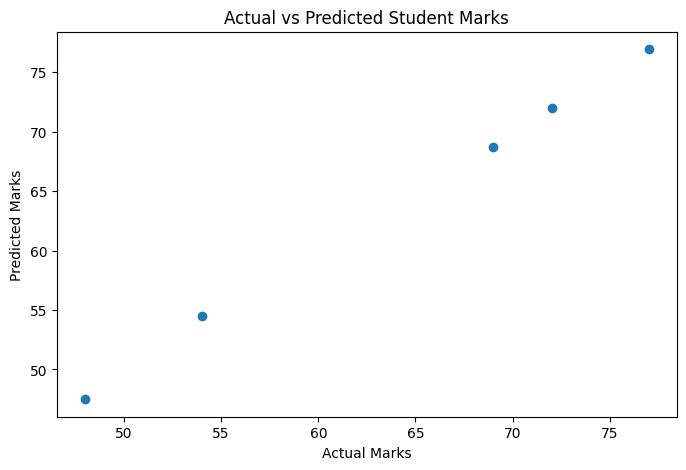

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Student Marks")

plt.show()

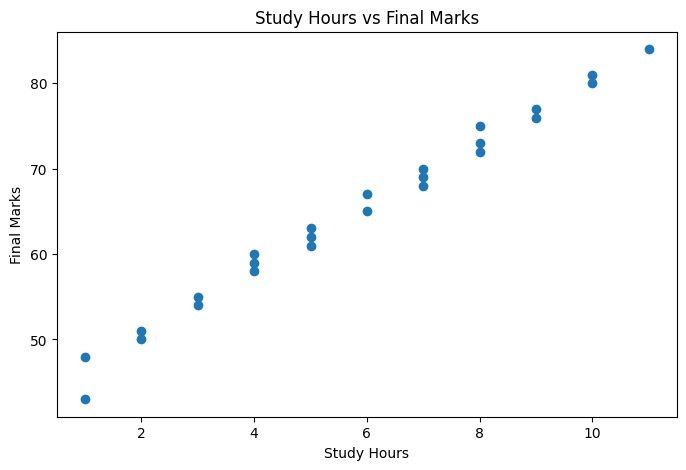

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["Study_Hours"], df["Final_Marks"])

plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")

plt.show()